# Семантическая сегментация подводных изображений (SUIM)

**Датасет:** SUIM — Semantic Segmentation of Underwater Imagery  
**Библиотека:** `segmentation_models.pytorch`  

## Структура работы
1. Выбор начальных условий (датасет + метрики)
2. Бейзлайн — обучение моделей из smp
3. Улучшение бейзлайна — гипотезы и эксперименты
4. Самостоятельная имплементация U-Net

## 0. Установка зависимостей

In [1]:
!pip install segmentation-models-pytorch albumentations torchmetrics -q

## 1. Выбор начальных условий

###  Обоснование датасета

**SUIM (Semantic Segmentation of Underwater Imagery)** — датасет подводных изображений с попиксельной разметкой 8 классов.

**Практическая задача:** автономные подводные аппараты (AUV) должны понимать окружение:
- Обнаруживать людей-дайверов для безопасности
- Распознавать морских роботов/инструменты
- Картировать морское дно, рифы, водоросли
- Находить затонувшие объекты

Применения: морская робототехника, мониторинг экосистем, подводная инспекция инфраструктуры.

**Классы SUIM:**
| Класс | Описание | RGB в маске |
|-------|----------|-------------|
| 0 | Background / Water (BW) | (0, 0, 0) |
| 1 | Human Divers (HD) | (0, 0, 255) |
| 2 | Aquatic Plants / Fauna (PF) | (0, 255, 0) |
| 3 | Wrecks / Ruins (WR) | (0, 255, 255) |
| 4 | Robots / Instruments (RO) | (255, 0, 0) |
| 5 | Reefs / Invertebrates (RI) | (255, 0, 255) |
| 6 | Fish / Vertebrates (FV) | (255, 255, 0) |
| 7 | Sea-floor / Rocks (SR) | (255, 255, 255) |

### 1b. Обоснование метрик

**mIoU (mean Intersection over Union)** — основная метрика семантической сегментации:
- Стандарт де-факто в литературе (Pascal VOC, COCO)
- Устойчива к дисбалансу классов (редкие классы не теряются)
- Формула: IoU_c = TP_c / (TP_c + FP_c + FN_c), mIoU = mean по классам

**Dice Score (F1 per class)** — дополнительная метрика:
- Особенно информативна для редких классов (HD, RO)
- Формула: Dice_c = 2*TP_c / (2*TP_c + FP_c + FN_c)

**Pixel Accuracy** — вспомогательная:
- Интуитивно понятна, но обманчива при дисбалансе (фон доминирует)
- Используем как дополнительный ориентир

## Импорты

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchmetrics import JaccardIndex
from torchmetrics.segmentation import DiceScore

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"{DEVICE}")

/home/user/anaconda3/envs/med_n/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [4]:
!nvidia-smi

Wed Apr 22 14:02:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:13:00.0 Off |                    0 |
| N/A   52C    P0            133W /  300W |   16721MiB /  81920MiB |     45%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))  
print(torch.cuda.mem_get_info()) 

True
NVIDIA A100 80GB PCIe
(67823730688, 85093777408)


## Dataset

In [6]:
class SUIMDataset(Dataset):
    def __init__(self, img_dir: Path, mask_dir: Path, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        img_stems = {p.stem for p in img_dir.glob("*.jpg")}
        mask_stems = {p.stem for p in mask_dir.glob("*.bmp")}
        self.stems = sorted(img_stems & mask_stems)
        print(f"Найдено пар: {len(self.stems)}")

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        image = np.array(Image.open(self.img_dir / f"{stem}.jpg").convert("RGB"))
        mask_rgb = np.array(Image.open(self.mask_dir / f"{stem}.bmp").convert("RGB"))

        if image.shape[:2] != mask_rgb.shape[:2]:
            mask_pil = Image.fromarray(mask_rgb).resize(
                (image.shape[1], image.shape[0]),  # (W, H)
                resample=Image.NEAREST  #чтобы не смешивать цвета классов!
            )
            mask_rgb = np.array(mask_pil)

        mask = rgb_to_mask(mask_rgb).astype(np.int64)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"].long()
        return image, mask

In [7]:
DATA_ROOT = Path("archive-2")  

TRAIN_IMG_DIR  = DATA_ROOT / "train_val" / "images"
TRAIN_MASK_DIR = DATA_ROOT / "train_val" / "masks"
TEST_IMG_DIR   = DATA_ROOT / "TEST" / "images"
TEST_MASK_DIR  = DATA_ROOT / "TEST" / "masks"

NUM_CLASSES = 8
IMG_SIZE = 256  

PALETTE = [
    (0,   0,   0),    # 0: Background / Water
    (0,   0,   255),  # 1: Human Divers
    (0,   255, 0),    # 2: Aquatic Plants
    (0,   255, 255),  # 3: Wrecks / Ruins
    (255, 0,   0),    # 4: Robots / Instruments
    (255, 0,   255),  # 5: Reefs / Invertebrates
    (255, 255, 0),    # 6: Fish / Vertebrates
    (255, 255, 255),  # 7: Sea-floor / Rocks
]

def rgb_to_mask(mask_rgb: np.ndarray) -> np.ndarray:
    mask = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for class_idx, rgb in enumerate(PALETTE):
        match = np.all(mask_rgb == np.array(rgb, dtype=np.uint8), axis=-1)
        mask[match] = class_idx
    return mask

CLASS_NAMES = [
    "Background", "Human Divers", "Aquatic Plants",
    "Wrecks/Ruins", "Robots", "Reefs", "Fish", "Sea-floor"
]



In [8]:
baseline_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)  

augmented_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], is_check_shapes=False)  

Поставим побольше batch_size чтобы сократить время обучения на А100 и не давать ей простаивать 

In [9]:
train_dataset = SUIMDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=baseline_transform)
test_dataset  = SUIMDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  transform=baseline_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Найдено пар: 1525
Найдено пар: 110
Train batches: 48, Test batches: 4


## Визуализация датасета

Найдено пар: 1525


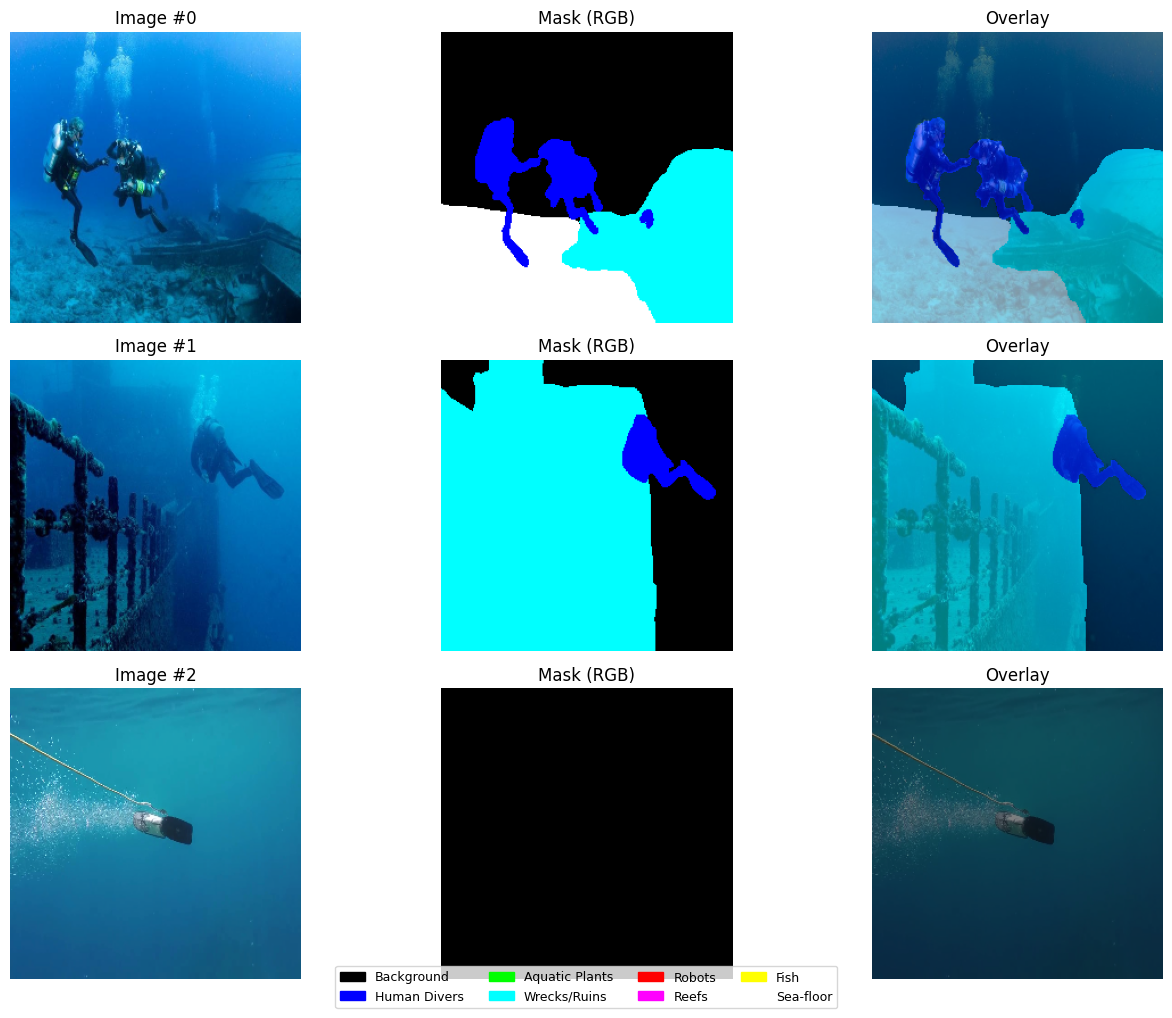

In [10]:
from matplotlib.patches import Patch

# Цвета
VIZ_COLORS = np.array(PALETTE, dtype=np.uint8)

def mask_to_rgb(mask: np.ndarray) -> np.ndarray:
    """(H, W) -> RGB (H, W, 3) """
    return VIZ_COLORS[mask]

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
raw_dataset = SUIMDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)  

for i, ax_row in enumerate(axes):
    img_t, mask_t = train_dataset[i]
    img_np = denormalize(img_t)
    mask_np = mask_t.numpy()

    ax_row[0].imshow(img_np)
    ax_row[0].set_title(f"Image #{i}")
    ax_row[0].axis("off")

    ax_row[1].imshow(mask_to_rgb(mask_np))
    ax_row[1].set_title("Mask (RGB)")
    ax_row[1].axis("off")

    ax_row[2].imshow(img_np)
    ax_row[2].imshow(mask_to_rgb(mask_np), alpha=0.5)
    ax_row[2].set_title("Overlay")
    ax_row[2].axis("off")



legend_patches = [Patch(color=np.array(c)/255, label=n) for c, n in zip(PALETTE, CLASS_NAMES)]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

Посмотрим на распределение классов 

Считаем распределение классов в train
Найдено пар: 1525


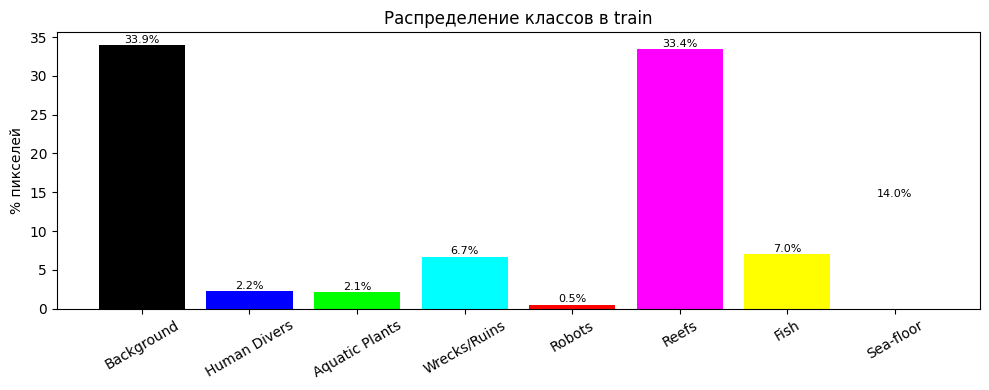

In [ ]:
print("Считаем распределение классов в train")
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
raw_train = SUIMDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)

for _, mask in raw_train:
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy()
    for c in range(NUM_CLASSES):
        class_counts[c] += (mask == c).sum()

total = class_counts.sum()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, class_counts / total * 100, color=[np.array(c)/255 for c in PALETTE])
ax.set_ylabel("% пикселей")
ax.set_title("Распределение классов в train")
ax.tick_params(axis='x', rotation=30)
for bar, cnt in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{cnt/total*100:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Метрики и утилиты обучения

Чтобы ускорить обучение также будем использовать  Mixed Precision (AMP) — обучение в float16, в среднем по замерам ускоряет в 2-3 раза на A100

In [11]:
from torch.cuda.amp import autocast, GradScaler


# Вместо DiceScore — считаем через IoU: Dice = 2*IoU / (1 + IoU)
def get_metrics(num_classes=NUM_CLASSES, device=DEVICE):
    return {
        "mIoU": JaccardIndex(task="multiclass", num_classes=num_classes, average="macro").to(device),
        "mIoU_per_class": JaccardIndex(task="multiclass", num_classes=num_classes, average="none").to(device),
        "dice": JaccardIndex(task="multiclass", num_classes=num_classes, average="macro").to(device),  
        "pixel_acc": JaccardIndex(task="multiclass", num_classes=num_classes, average="micro").to(device),
    }

scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        
        with autocast():  
            preds = model(images)
            loss = criterion(preds, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=NUM_CLASSES):
    model.eval()
    metrics = get_metrics(num_classes, device)
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        loss = criterion(preds, masks)
        total_loss += loss.item()
        
        pred_classes = preds.argmax(dim=1)  # (B, H, W) — int
        
        metrics["mIoU"](pred_classes, masks)
        metrics["mIoU_per_class"](pred_classes, masks)
        metrics["dice"](pred_classes, masks)
        metrics["pixel_acc"](pred_classes, masks)

    iou = metrics["mIoU"].compute().item()

    return {
        "loss": total_loss / len(loader),
        "mIoU": iou,
        "mIoU_per_class": metrics["mIoU_per_class"].compute().cpu().numpy(),
        "dice": 2 * iou / (1 + iou),
        "pixel_acc": metrics["pixel_acc"].compute().item(),
    }


def train_model(model, train_loader, test_loader, optimizer, criterion, scheduler=None,
                num_epochs=20, device=DEVICE, model_name="model"):
    history = {"train_loss": [], "val_loss": [], "mIoU": [], "dice": [], "pixel_acc": []}
    best_miou = 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, test_loader, criterion, device)

        if scheduler:
            scheduler.step(val_metrics["mIoU"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["mIoU"].append(val_metrics["mIoU"])
        history["dice"].append(val_metrics["dice"])
        history["pixel_acc"].append(val_metrics["pixel_acc"])

        if val_metrics["mIoU"] > best_miou:
            best_miou = val_metrics["mIoU"]
            torch.save(model.state_dict(), f"{model_name}_best.pth")

        print(f"Epoch [{epoch:02d}/{num_epochs}] "
              f"train_loss={train_loss:.4f} "
              f"val_loss={val_metrics['loss']:.4f} "
              f"mIoU={val_metrics['mIoU']:.4f} "
              f"Dice={val_metrics['dice']:.4f} "
              f"PixAcc={val_metrics['pixel_acc']:.4f}")

    print(f"\nЛучший mIoU: {best_miou:.4f}")
    return history

def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[1].plot(history["mIoU"],      label="mIoU")
    axes[1].plot(history["dice"],      label="Dice")
    axes[1].plot(history["pixel_acc"], label="Pixel Acc")
    axes[1].set_title(f"{title} — Metrics")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1743001/1837379254.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 2. Бейзлайн — модели из segmentation_models_pytorch

Обучаем две архитектуры:
- **U-Net + ResNet34** — лёгкий и быстрый baseline
- **FPN + ResNet34** — Feature Pyramid Network, лучше на разных масштабах объектов

Энкодеры предобучены на ImageNet. Лосс: CrossEntropyLoss 

Так как поставили batch_size = 64 пропорционально увеличим lr чтобы градиент не был слишком средним(linear scaling rule.)

BASELINE 1: U-Net + ResNet34


/tmp/ipykernel_2653442/1837379254.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/20] train_loss=1.3095 val_loss=1.3354 mIoU=0.1529 Dice=0.2653 PixAcc=0.4004
Epoch [02/20] train_loss=1.1797 val_loss=1.2279 mIoU=0.1837 Dice=0.3104 PixAcc=0.4332
Epoch [03/20] train_loss=1.1322 val_loss=1.1235 mIoU=0.2222 Dice=0.3636 PixAcc=0.4525
Epoch [04/20] train_loss=1.0745 val_loss=1.1766 mIoU=0.2047 Dice=0.3399 PixAcc=0.4197
Epoch [05/20] train_loss=1.0774 val_loss=1.1483 mIoU=0.1955 Dice=0.3271 PixAcc=0.4252
Epoch [06/20] train_loss=1.0350 val_loss=1.0209 mIoU=0.2751 Dice=0.4315 PixAcc=0.5076
Epoch [07/20] train_loss=1.0206 val_loss=0.9935 mIoU=0.2783 Dice=0.4354 PixAcc=0.4975
Epoch [08/20] train_loss=0.9889 val_loss=1.1018 mIoU=0.2427 Dice=0.3906 PixAcc=0.4335
Epoch [09/20] train_loss=0.9911 val_loss=1.2698 mIoU=0.2225 Dice=0.3640 PixAcc=0.4004
Epoch [10/20] train_loss=0.9683 val_loss=1.0622 mIoU=0.2886 Dice=0.4479 PixAcc=0.4879
Epoch [11/20] train_loss=0.9653 val_loss=1.0083 mIoU=0.2848 Dice=0.4433 PixAcc=0.4840
Epoch [12/20] train_loss=0.9380 val_loss=0.8918 mIoU=0

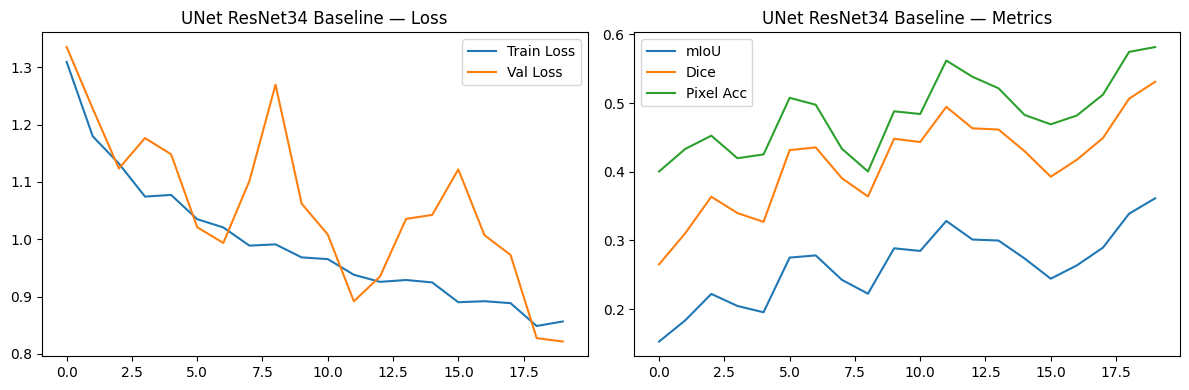

In [36]:
EPOCHS_BASELINE = 20

print("=" * 50)
print("BASELINE 1: U-Net + ResNet34")
print("=" * 50)

unet_baseline = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

criterion_ce = nn.CrossEntropyLoss()
optimizer_unet = optim.Adam(unet_baseline.parameters(), lr=4e-3)

history_unet_baseline = train_model(
    unet_baseline, train_loader, test_loader,
    optimizer_unet, criterion_ce,
    num_epochs=EPOCHS_BASELINE, model_name="unet_baseline"
)
plot_history(history_unet_baseline, "UNet ResNet34 Baseline")

Теперь обучим FPN + ResNet34

BASELINE 2: FPN + ResNet34


/tmp/ipykernel_2857405/1837379254.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/20] train_loss=2.2522 val_loss=1.5047 mIoU=0.1265 Dice=0.2246 PixAcc=0.3481
Epoch [02/20] train_loss=1.3542 val_loss=1.2758 mIoU=0.1914 Dice=0.3214 PixAcc=0.4405
Epoch [03/20] train_loss=1.2120 val_loss=1.1221 mIoU=0.2267 Dice=0.3696 PixAcc=0.4700
Epoch [04/20] train_loss=1.1569 val_loss=1.1312 mIoU=0.2375 Dice=0.3838 PixAcc=0.4806
Epoch [05/20] train_loss=1.1212 val_loss=1.1812 mIoU=0.2397 Dice=0.3868 PixAcc=0.4656
Epoch [06/20] train_loss=1.0792 val_loss=1.0194 mIoU=0.2662 Dice=0.4205 PixAcc=0.5051
Epoch [07/20] train_loss=1.0141 val_loss=0.9604 mIoU=0.2744 Dice=0.4307 PixAcc=0.5055
Epoch [08/20] train_loss=0.9881 val_loss=0.9767 mIoU=0.2970 Dice=0.4580 PixAcc=0.5076
Epoch [09/20] train_loss=0.9814 val_loss=1.0364 mIoU=0.2810 Dice=0.4388 PixAcc=0.5180
Epoch [10/20] train_loss=0.9585 val_loss=1.0930 mIoU=0.2542 Dice=0.4054 PixAcc=0.4414
Epoch [11/20] train_loss=0.9482 val_loss=1.0057 mIoU=0.2770 Dice=0.4339 PixAcc=0.5039
Epoch [12/20] train_loss=0.9394 val_loss=0.9908 mIoU=0

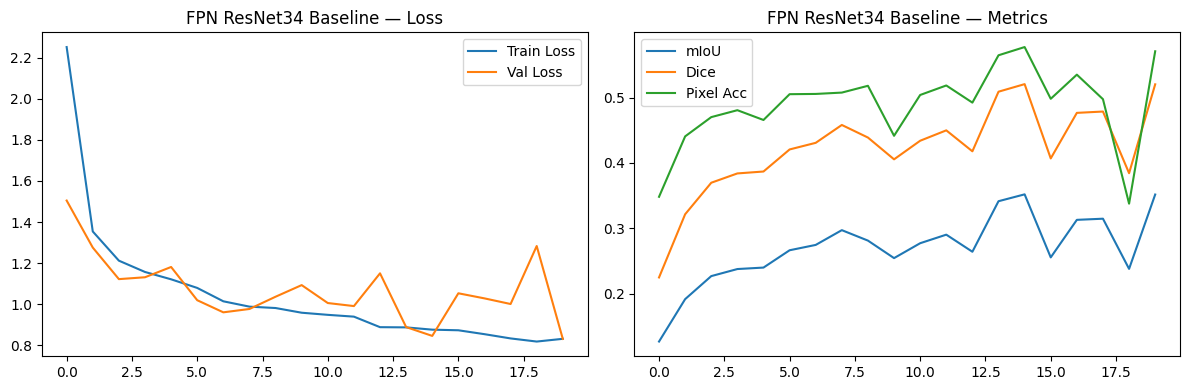

In [ ]:
EPOCHS_BASELINE = 20

criterion_ce = nn.CrossEntropyLoss()

print("=" * 50)
print("BASELINE 2: FPN + ResNet34")
print("=" * 50)

fpn_baseline = smp.FPN(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

optimizer_fpn = optim.Adam(fpn_baseline.parameters(), lr=4e-3)

history_fpn_baseline = train_model(
    fpn_baseline, train_loader, test_loader,
    optimizer_fpn, criterion_ce,
    num_epochs=EPOCHS_BASELINE, model_name="fpn_baseline"
)
plot_history(history_fpn_baseline, "FPN ResNet34 Baseline")

In [ ]:
def get_final_metrics(model_path, model, loader, criterion, device):
    model.load_state_dict(torch.load(model_path, map_location=device))
    return evaluate(model, loader, criterion, device)

results_unet_bl = get_final_metrics("unet_baseline_best.pth", unet_baseline, test_loader, criterion_ce, DEVICE)
results_fpn_bl  = get_final_metrics("fpn_baseline_best.pth",  fpn_baseline,  test_loader, criterion_ce, DEVICE)

print("\n" + "=" * 60)
print("ИТОГИ БЕЙЗЛАЙНА")
print("=" * 60)
print(f"{'Модель':<25} {'mIoU':>8} {'Dice':>8} {'PixAcc':>8}")
print("-" * 52)
print(f"{'UNet + ResNet34':<25} {results_unet_bl['mIoU']:>8.4f} {results_unet_bl['dice']:>8.4f} {results_unet_bl['pixel_acc']:>8.4f}")
print(f"{'FPN + ResNet34':<25} {results_fpn_bl['mIoU']:>8.4f} {results_fpn_bl['dice']:>8.4f} {results_fpn_bl['pixel_acc']:>8.4f}")

print("\nIoU по классам (UNet):")
for name, iou in zip(CLASS_NAMES, results_unet_bl['mIoU_per_class']):
    print(f"  {name:<20}: {iou:.4f}")

print("\nIoU по классам (FPN):")
for name, iou in zip(CLASS_NAMES, results_fpn_bl['mIoU_per_class']):
    print(f"  {name:<20}: {iou:.4f}")

/tmp/ipykernel_2857405/4213251625.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))



ИТОГИ БЕЙЗЛАЙНА
Модель                        mIoU     Dice   PixAcc
----------------------------------------------------
UNet + ResNet34             0.3614   0.5310   0.5814
FPN + ResNet34              0.3518   0.5205   0.5773

IoU по классам (UNet):
  Background          : 0.8202
  Human Divers        : 0.2868
  Aquatic Plants      : 0.0000
  Wrecks/Ruins        : 0.3770
  Robots              : 0.0000
  Reefs               : 0.5614
  Fish                : 0.3025
  Sea-floor           : 0.5437

IoU по классам (FPN):
  Background          : 0.8286
  Human Divers        : 0.3219
  Aquatic Plants      : 0.0000
  Wrecks/Ruins        : 0.2981
  Robots              : 0.0000
  Reefs               : 0.4720
  Fish                : 0.3128
  Sea-floor           : 0.5811


Бейзлайн выявил две ключевые проблемы которые нужно решить в п.3:

1)Дисбаланс классов → Aquatic Plants и Robots не предсказываются вообще.

Далее попробуем пофиксить: Dice Loss который явно оптимизирует IoU каждого класса независимо от его размера.

2)Нестабильность обучения → скачки Val Loss. 

Фиксим: ReduceLROnPlateau scheduler.

Мелкие объекты → Fish и Human Divers с низким IoU. Решение: аугментации + возможно увеличение разрешения с 256 до 320.

## 3. Улучшение бейзлайна

###  Гипотезы

| # | Гипотеза | Обоснование |
|---|----------|-------------|
| H1 | **Аугментации** (flip, color jitter, random crop) | Подводные изображения имеют специфические цвета (синеватый/зеленоватый сдвиг); данных мало — аугментации помогут генерализации |
| H2 | **Комбинированный лосс** (CE + Dice) | Dice Loss явно оптимизирует IoU, помогает при дисбалансе редких классов (HD, RO) |
| H3 | **LR Scheduler** (ReduceLROnPlateau) | Автоматически снижает LR при плато — улучшает сходимость |
| H4 | **Более мощный энкодер** (EfficientNet-b3) | Лучше извлекает признаки, но дольше обучается |

In [12]:
# H1: Аугментации 
augmented_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.4),
    A.RandomCrop(height=224, width=224, p=0.3),
    A.Resize(IMG_SIZE, IMG_SIZE),  
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_aug_dataset = SUIMDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=augmented_transform)
train_aug_loader  = DataLoader(train_aug_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

# H2: Комбинированный лосс CE + Dice
class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = smp.losses.DiceLoss(mode="multiclass")
        self.ce_w = ce_weight
        self.dice_w = dice_weight

    def forward(self, pred, target):
        return self.ce_w * self.ce(pred, target) + self.dice_w * self.dice(pred, target)

criterion_combined = CombinedLoss()



Найдено пар: 1525


Далее попробуем совместить все наши гипотезы: 

УЛУЧШЕННЫЙ БЕЙЗЛАЙН: UNet + ResNet34 + Aug + CombinedLoss + Scheduler


/tmp/ipykernel_1743001/1837379254.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/20] train_loss=1.0364 val_loss=1.1274 mIoU=0.1244 Dice=0.2213 PixAcc=0.2900
Epoch [02/20] train_loss=0.9988 val_loss=1.2080 mIoU=0.1631 Dice=0.2805 PixAcc=0.3840
Epoch [03/20] train_loss=0.9862 val_loss=0.9940 mIoU=0.1346 Dice=0.2373 PixAcc=0.3787
Epoch [04/20] train_loss=0.9865 val_loss=1.0031 mIoU=0.1635 Dice=0.2811 PixAcc=0.4066
Epoch [05/20] train_loss=0.9820 val_loss=0.9806 mIoU=0.1638 Dice=0.2814 PixAcc=0.4083
Epoch [06/20] train_loss=0.9622 val_loss=1.0432 mIoU=0.1560 Dice=0.2699 PixAcc=0.3896
Epoch [07/20] train_loss=0.9496 val_loss=0.9194 mIoU=0.2159 Dice=0.3552 PixAcc=0.4292
Epoch [08/20] train_loss=0.9424 val_loss=0.9184 mIoU=0.2194 Dice=0.3599 PixAcc=0.4251
Epoch [09/20] train_loss=0.9374 val_loss=0.8987 mIoU=0.2308 Dice=0.3751 PixAcc=0.4516
Epoch [10/20] train_loss=0.9222 val_loss=0.9482 mIoU=0.2118 Dice=0.3495 PixAcc=0.4514
Epoch [11/20] train_loss=0.9117 val_loss=0.9252 mIoU=0.2318 Dice=0.3764 PixAcc=0.4537
Epoch [12/20] train_loss=0.9165 val_loss=0.9077 mIoU=0

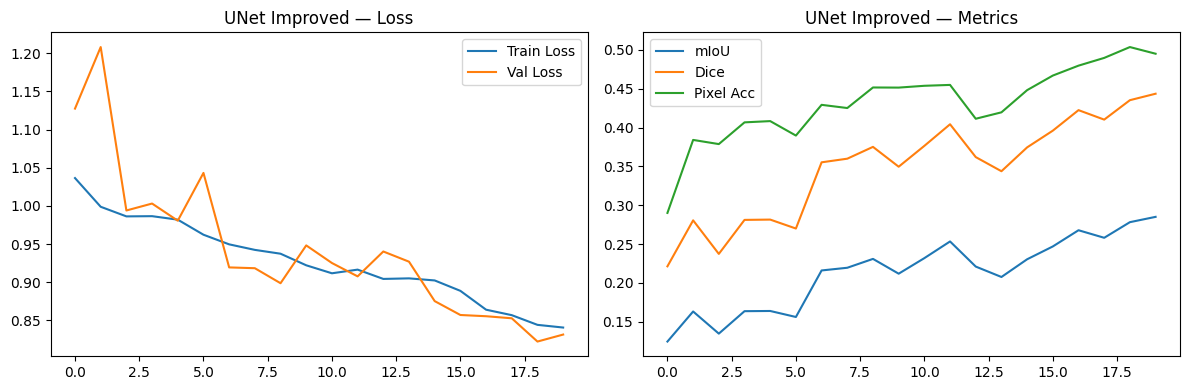

In [14]:
print("=" * 50)
print("УЛУЧШЕННЫЙ БЕЙЗЛАЙН: UNet + ResNet34 + Aug + CombinedLoss + Scheduler")
print("=" * 50)

EPOCHS_BASELINE = 20

unet_improved = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

optimizer_imp = optim.Adam(unet_improved.parameters(), lr=4e-3, weight_decay=1e-4)
# H3: LR Scheduler
scheduler_imp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_imp, mode="max", patience=3, factor=0.5, verbose=True)

history_unet_improved = train_model(
    unet_improved, train_aug_loader, test_loader,  # H1: аугментированный train
    optimizer_imp, criterion_combined,              # H2: combined loss
    scheduler=scheduler_imp,                        # H3: scheduler
    num_epochs=EPOCHS_BASELINE, model_name="unet_improved"
)
plot_history(history_unet_improved, "UNet Improved")

Так как комбинированный лосс, не будем повышать lr

УЛУЧШЕННЫЙ БЕЙЗЛАЙН: UNet + EfficientNet-b3 + Aug + CombinedLoss + Scheduler


/tmp/ipykernel_2857405/1837379254.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/20] train_loss=1.0732 val_loss=0.8974 mIoU=0.2008 Dice=0.3344 PixAcc=0.4431
Epoch [02/20] train_loss=0.8698 val_loss=0.7837 mIoU=0.2732 Dice=0.4291 PixAcc=0.5339
Epoch [03/20] train_loss=0.8085 val_loss=0.7294 mIoU=0.3031 Dice=0.4652 PixAcc=0.5705
Epoch [04/20] train_loss=0.7551 val_loss=0.6714 mIoU=0.3601 Dice=0.5295 PixAcc=0.6225
Epoch [05/20] train_loss=0.7060 val_loss=0.6815 mIoU=0.3653 Dice=0.5352 PixAcc=0.6100
Epoch [06/20] train_loss=0.6753 val_loss=0.6188 mIoU=0.4032 Dice=0.5747 PixAcc=0.6427
Epoch [07/20] train_loss=0.6388 val_loss=0.6108 mIoU=0.4502 Dice=0.6209 PixAcc=0.6476
Epoch [08/20] train_loss=0.5983 val_loss=0.5726 mIoU=0.4830 Dice=0.6514 PixAcc=0.6769
Epoch [09/20] train_loss=0.5645 val_loss=0.5590 mIoU=0.4992 Dice=0.6660 PixAcc=0.6903
Epoch [10/20] train_loss=0.5359 val_loss=0.5238 mIoU=0.5066 Dice=0.6725 PixAcc=0.6962
Epoch [11/20] train_loss=0.5327 val_loss=0.5273 mIoU=0.5089 Dice=0.6745 PixAcc=0.6891
Epoch [12/20] train_loss=0.5028 val_loss=0.5411 mIoU=0

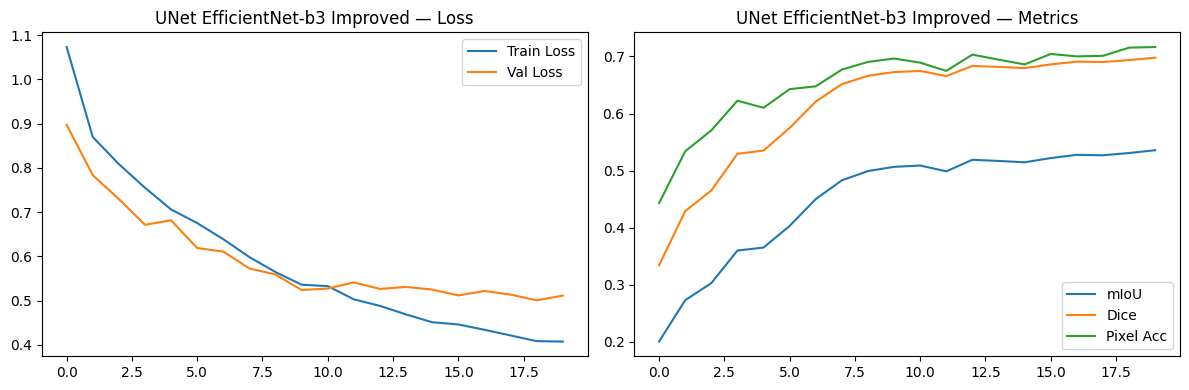

In [18]:
# H4: EfficientNet-b3 как энкодер

print("=" * 50)
print("УЛУЧШЕННЫЙ БЕЙЗЛАЙН: UNet + EfficientNet-b3 + Aug + CombinedLoss + Scheduler")
print("=" * 50)

unet_effnet = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

optimizer_eff = optim.Adam(unet_effnet.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_eff = optim.lr_scheduler.ReduceLROnPlateau(optimizer_eff, mode="max", patience=3, factor=0.5, verbose=True)

history_unet_effnet = train_model(
    unet_effnet, train_aug_loader, test_loader,
    optimizer_eff, criterion_combined,
    scheduler=scheduler_eff,
    num_epochs=EPOCHS_BASELINE, model_name="unet_effnet"
)
plot_history(history_unet_effnet, "UNet EfficientNet-b3 Improved")

Лучший mIoU: 0.5357 — прирост с 0.361 до 0.536, это +48% к бейзлайну.   


EfficientNet-b3 как энкодер дал основной прирост — более мощный feature extractor критичен для подводных изображений со сложной текстурой.

 Комбинация всех гипотез (аугментации + Dice Loss + scheduler + лучший энкодер) дала суммарный прирост ~48%.


/tmp/ipykernel_1743001/2302819335.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))



СРАВНЕНИЕ: БЕЙЗЛАЙН vs УЛУЧШЕННЫЙ
Модель                                  mIoU     Dice   PixAcc
--------------------------------------------------------------
UNet ResNet34 (baseline)              0.3614   0.5310   0.5814
FPN ResNet34 (baseline)               0.3518   0.5205   0.5773
UNet ResNet34 (improved)              0.2850   0.4435   0.4950
UNet EfficientNet-b3 (improved)       0.5357   0.6977   0.7163


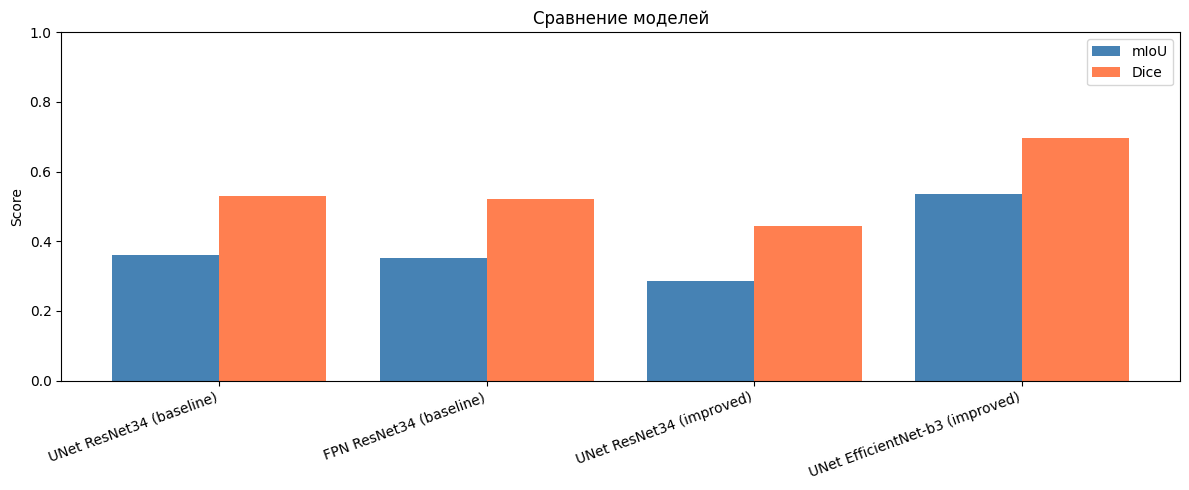

In [25]:
results_unet_imp = get_final_metrics("unet_improved_best.pth", unet_improved, test_loader, criterion_combined, DEVICE)
results_effnet   = get_final_metrics("unet_effnet_best.pth",   unet_effnet,   test_loader, criterion_combined, DEVICE)
results_unet_bl = get_final_metrics("unet_baseline_best.pth", unet_baseline, test_loader, criterion_ce, DEVICE)
results_fpn_bl = get_final_metrics("fpn_baseline_best.pth", fpn_baseline, test_loader, criterion_ce, DEVICE)

print("\n" + "=" * 70)
print("СРАВНЕНИЕ: БЕЙЗЛАЙН vs УЛУЧШЕННЫЙ")
print("=" * 70)
print(f"{'Модель':<35} {'mIoU':>8} {'Dice':>8} {'PixAcc':>8}")
print("-" * 62)
rows = [
    ("UNet ResNet34 (baseline)",        results_unet_bl),
    ("FPN ResNet34 (baseline)",         results_fpn_bl),
    ("UNet ResNet34 (improved)",        results_unet_imp),
    ("UNet EfficientNet-b3 (improved)", results_effnet),
]
for name, r in rows:
    print(f"{name:<35} {r['mIoU']:>8.4f} {r['dice']:>8.4f} {r['pixel_acc']:>8.4f}")

names = [r[0] for r in rows]
miou_vals = [r[1]['mIoU'] for r in rows]
dice_vals = [r[1]['dice'] for r in rows]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, miou_vals, 0.4, label='mIoU', color='steelblue')
ax.bar(x + 0.2, dice_vals, 0.4, label='Dice', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel("Score")
ax.set_title("Сравнение моделей")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Гипотеза  (смена энкодера на EfficientNet-b3) дала наибольший прирост — mIoU вырос с 0.361 до 0.536 (+48%). EfficientNet-b3 извлекает значительно более богатые признаки благодаря compound scaling — одновременному масштабированию глубины, ширины и разрешения сети.


Гипотезы  (аугментации + Dice Loss + scheduler) в связке с ResNet34 не дали прироста из-за нестабильности при повышенном LR


## 4. Самостоятельная имплементация U-Net

Реализуем U-Net :
- Encoder (4 уровня понижения разрешения через MaxPool)
- Bottleneck
- Decoder с skip-connections (конкатенация feature maps)
- Выходная голова 1×1 conv

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.conv(x)  
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    """ConvTranspose2d (upsampling) + конкатенация skip + DoubleConv."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels * 2, out_channels)  

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            skip = skip[:, :, :x.shape[2], :x.shape[3]]
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNetCustom(nn.Module):
    """
    encoder → bottleneck → 4 уровня decoder → 1×1 conv голова.
    """
    def __init__(self, in_channels=3, num_classes=8, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        prev_ch = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(prev_ch, f))
            prev_ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        self.decoders = nn.ModuleList()
        prev_ch = features[-1] * 2
        for f in reversed(features):
            self.decoders.append(DecoderBlock(prev_ch, f))
            prev_ch = f

        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skips = []
        for encoder in self.encoders:
            x, skip = encoder(x)
            skips.append(skip)

        x = self.bottleneck(x)

        for decoder, skip in zip(self.decoders, reversed(skips)):
            x = decoder(x, skip)

        return self.head(x)


model_test = UNetCustom(num_classes=NUM_CLASSES)
dummy = torch.randn(2, 3, 256, 256)
out = model_test(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")

total_params = sum(p.numel() for p in model_test.parameters())
print(f"Параметров: {total_params:,} ({total_params/1e6:.1f}M)")

Input:  torch.Size([2, 3, 256, 256])
Output: torch.Size([2, 8, 256, 256])
Параметров: 31,038,088 (31.0M)


CUSTOM U-Net (без улучшений, baseline)


/tmp/ipykernel_2857405/1837379254.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/20] train_loss=1.4105 val_loss=1.3067 mIoU=0.1684 Dice=0.2883 PixAcc=0.4157
Epoch [02/20] train_loss=1.2170 val_loss=1.2713 mIoU=0.1656 Dice=0.2842 PixAcc=0.4066
Epoch [03/20] train_loss=1.1698 val_loss=1.2058 mIoU=0.2089 Dice=0.3456 PixAcc=0.4382
Epoch [04/20] train_loss=1.1451 val_loss=1.1592 mIoU=0.1990 Dice=0.3319 PixAcc=0.4401
Epoch [05/20] train_loss=1.1123 val_loss=1.1312 mIoU=0.2315 Dice=0.3760 PixAcc=0.4613
Epoch [06/20] train_loss=1.0860 val_loss=1.1099 mIoU=0.2222 Dice=0.3636 PixAcc=0.4593
Epoch [07/20] train_loss=1.0752 val_loss=1.2018 mIoU=0.2546 Dice=0.4059 PixAcc=0.4407
Epoch [08/20] train_loss=1.0557 val_loss=1.1244 mIoU=0.2266 Dice=0.3695 PixAcc=0.4642
Epoch [09/20] train_loss=1.0396 val_loss=1.0919 mIoU=0.2787 Dice=0.4359 PixAcc=0.4943
Epoch [10/20] train_loss=1.0178 val_loss=1.0186 mIoU=0.2728 Dice=0.4286 PixAcc=0.5039
Epoch [11/20] train_loss=1.0053 val_loss=1.1138 mIoU=0.2696 Dice=0.4247 PixAcc=0.4935
Epoch [12/20] train_loss=1.0042 val_loss=1.1374 mIoU=0

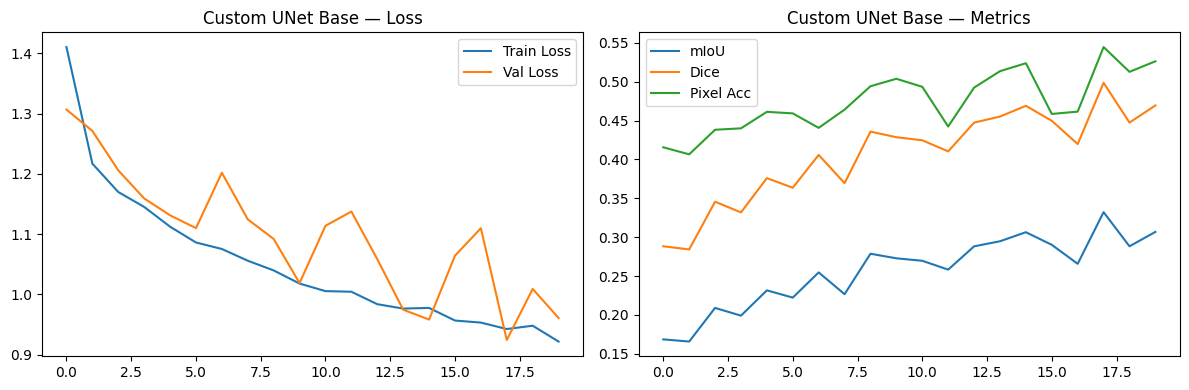

In [ ]:
print("=" * 50)
print("CUSTOM U-Net (без улучшений, baseline)")
print("=" * 50)

unet_custom_base = UNetCustom(num_classes=NUM_CLASSES).to(DEVICE)
optimizer_cust_base = optim.Adam(unet_custom_base.parameters(), lr=1e-3)

history_custom_base = train_model(
    unet_custom_base, train_loader, test_loader,  # без аугментаций
    optimizer_cust_base, criterion_ce,
    num_epochs=EPOCHS_BASELINE, model_name="unet_custom_base"
)
plot_history(history_custom_base, "Custom UNet Base")

CUSTOM U-Net + Aug + CombinedLoss + Scheduler


/tmp/ipykernel_2857405/1837379254.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/20] train_loss=1.0433 val_loss=1.0453 mIoU=0.1155 Dice=0.2071 PixAcc=0.3490
Epoch [02/20] train_loss=1.0061 val_loss=1.0209 mIoU=0.1383 Dice=0.2430 PixAcc=0.3785
Epoch [03/20] train_loss=0.9963 val_loss=1.0455 mIoU=0.1232 Dice=0.2194 PixAcc=0.3603
Epoch [04/20] train_loss=0.9909 val_loss=1.0167 mIoU=0.1583 Dice=0.2734 PixAcc=0.3966
Epoch [05/20] train_loss=0.9966 val_loss=1.0029 mIoU=0.1591 Dice=0.2746 PixAcc=0.3892
Epoch [06/20] train_loss=0.9831 val_loss=0.9557 mIoU=0.1828 Dice=0.3090 PixAcc=0.4164
Epoch [07/20] train_loss=0.9637 val_loss=0.9543 mIoU=0.1797 Dice=0.3046 PixAcc=0.3994
Epoch [08/20] train_loss=0.9576 val_loss=0.9428 mIoU=0.1923 Dice=0.3226 PixAcc=0.4065
Epoch [09/20] train_loss=0.9551 val_loss=0.9975 mIoU=0.1708 Dice=0.2917 PixAcc=0.3908
Epoch [10/20] train_loss=0.9394 val_loss=0.9324 mIoU=0.1990 Dice=0.3319 PixAcc=0.4260
Epoch [11/20] train_loss=0.9431 val_loss=0.9252 mIoU=0.2125 Dice=0.3505 PixAcc=0.4147
Epoch [12/20] train_loss=0.9388 val_loss=0.9107 mIoU=0

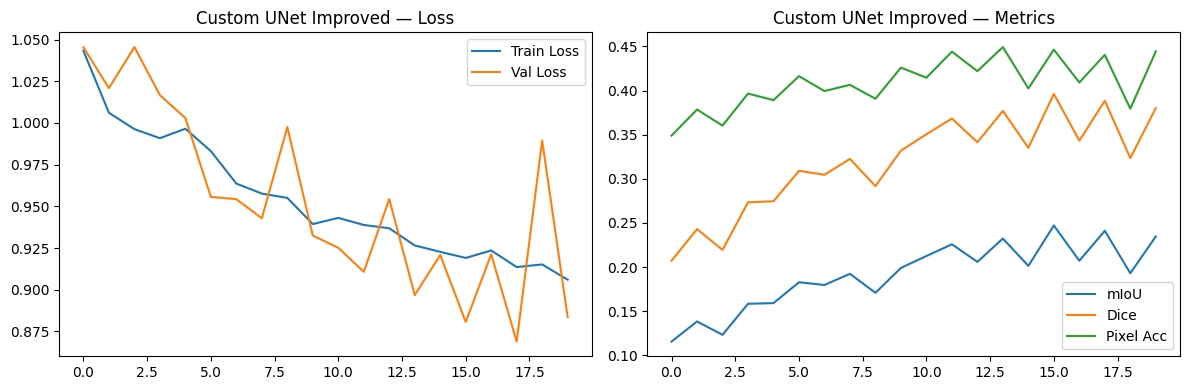

In [23]:
print("=" * 50)
print("CUSTOM U-Net + Aug + CombinedLoss + Scheduler")
print("=" * 50)
unet_custom_imp = UNetCustom(num_classes=NUM_CLASSES).to(DEVICE)
optimizer_cust_imp = optim.Adam(unet_custom_imp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cust = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cust_imp, mode="max", patience=3, factor=0.5, verbose=True
)

history_custom_imp = train_model(
    unet_custom_imp, 
    train_aug_loader,    
    test_loader,
    optimizer_cust_imp, 
    criterion_combined,   
    scheduler=scheduler_cust,
    num_epochs=EPOCHS_BASELINE, 
    model_name="unet_custom_imp"
)
plot_history(history_custom_imp, "Custom UNet Improved")


/tmp/ipykernel_2857405/4213251625.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))



ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Модель                                     mIoU     Dice   PixAcc
------------------------------------------------------------------
[smp] UNet ResNet34 (baseline)           0.3614   0.5310   0.5814
[smp] FPN ResNet34 (baseline)            0.3518   0.5205   0.5773
[smp] UNet ResNet34 (improved)           0.2618   0.4149   0.4790
[smp] UNet EfficientNet-b3 (improved)    0.5357   0.6977   0.7163
[custom] UNet (baseline)                 0.3322   0.4987   0.5447
[custom] UNet (improved)                 0.2471   0.3963   0.4464


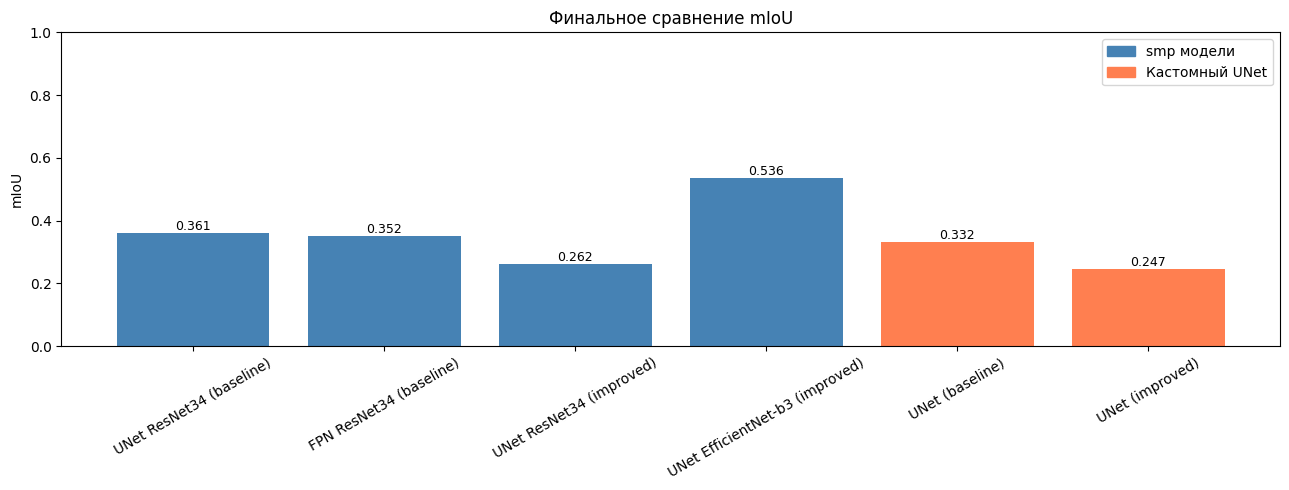

In [ ]:
from matplotlib.patches import Patch

results_custom_base = get_final_metrics("unet_custom_base_best.pth", unet_custom_base, test_loader, criterion_ce, DEVICE)
results_custom_imp  = get_final_metrics("unet_custom_imp_best.pth",  unet_custom_imp,  test_loader, criterion_combined, DEVICE)

print("\n" + "=" * 72)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 72)
print(f"{'Модель':<38} {'mIoU':>8} {'Dice':>8} {'PixAcc':>8}")
print("-" * 66)

all_results = [
    ("[smp] UNet ResNet34 (baseline)",        results_unet_bl),
    ("[smp] FPN ResNet34 (baseline)",         results_fpn_bl),
    ("[smp] UNet ResNet34 (improved)",        results_unet_imp),
    ("[smp] UNet EfficientNet-b3 (improved)", results_effnet),
    ("[custom] UNet (baseline)",              results_custom_base),
    ("[custom] UNet (improved)",              results_custom_imp),
]
for name, r in all_results:
    print(f"{name:<38} {r['mIoU']:>8.4f} {r['dice']:>8.4f} {r['pixel_acc']:>8.4f}")

names = [r[0].split("]")[1].strip() for r in all_results]
miou_vals = [r[1]['mIoU'] for r in all_results]
colors = ['steelblue']*4 + ['coral']*2

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(names, miou_vals, color=colors)
ax.set_ylabel("mIoU")
ax.set_title("Финальное сравнение mIoU")
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=30)
for bar, v in zip(bars, miou_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.3f}", ha='center', fontsize=9)

ax.legend(handles=[
    Patch(color='steelblue', label='smp модели'),
    Patch(color='coral', label='Кастомный UNet')
])
plt.tight_layout()
plt.show()

## Выводы

По кастомному UNet (п.4):

Кастомный UNet baseline показал mIoU=0.332, что сопоставимо с smp-бейзлайном (0.361) — разрыв всего 8%. Это говорит о том что архитектура U-Net реализована корректно.

 Однако кастомный UNet improved (0.247) снова деградировал по той же причине что и smp ResNet34 improved — несовместимость повышенного LR с Dice Loss.
 


Главный вывод всей работы:
Ключевой фактор качества — предобученный энкодер. UNet с EfficientNet-b3 (ImageNet pretrain) превзошёл кастомный UNet с нуля на 61% (0.536 vs 0.332) при одинаковой архитектуре декодера.

 На небольшом датасете (~1500 изображений) обучить энкодер с нуля до сопоставимого качества практически невозможно без TF


Иерархия факторов влияния на качество:

Качество предобученного энкодера — самое важное(+48% от ResNet34 → EfficientNet-b3)

Функция потерь — Dice Loss критична при дисбалансе классов

LR Scheduler — стабилизирует обучение

Аугментации — улучшают генерализацию

Архитектура декодера — наименее значимый фактор при прочих равных


## Визуализация предсказаний

/tmp/ipykernel_1743001/2854977660.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_baseline.load_state_dict(torch.load("unet_baseline_best.pth", map_location=DEVICE

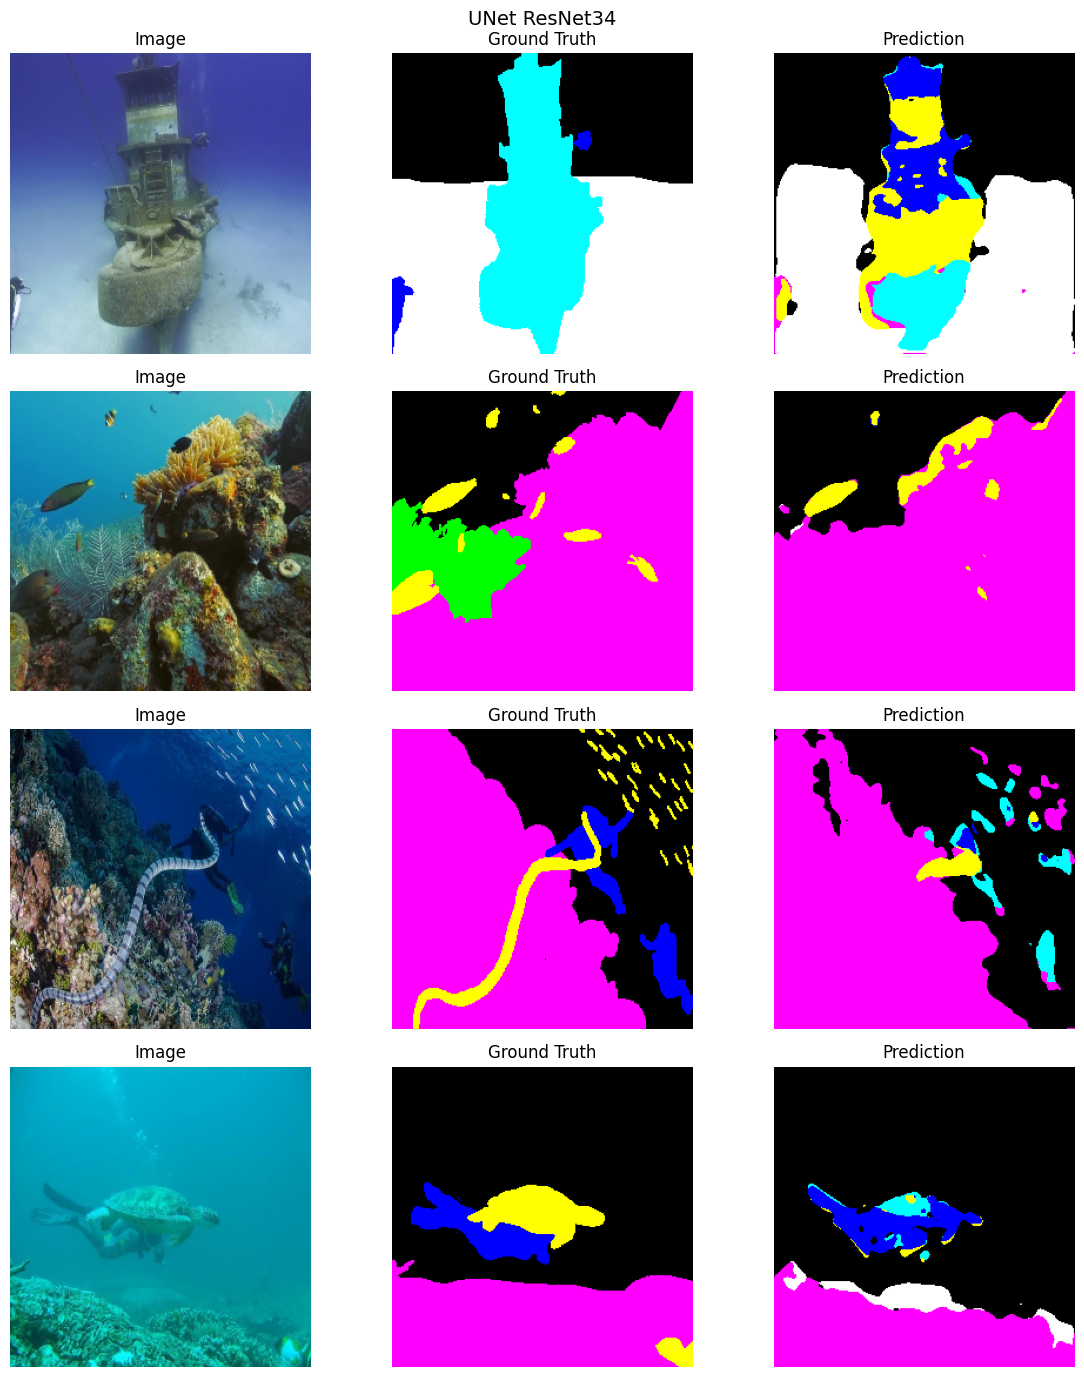

/tmp/ipykernel_1743001/2854977660.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_custom_imp.load_state_dict(torch.load("unet_custom_imp_best.pth", map_location=DE

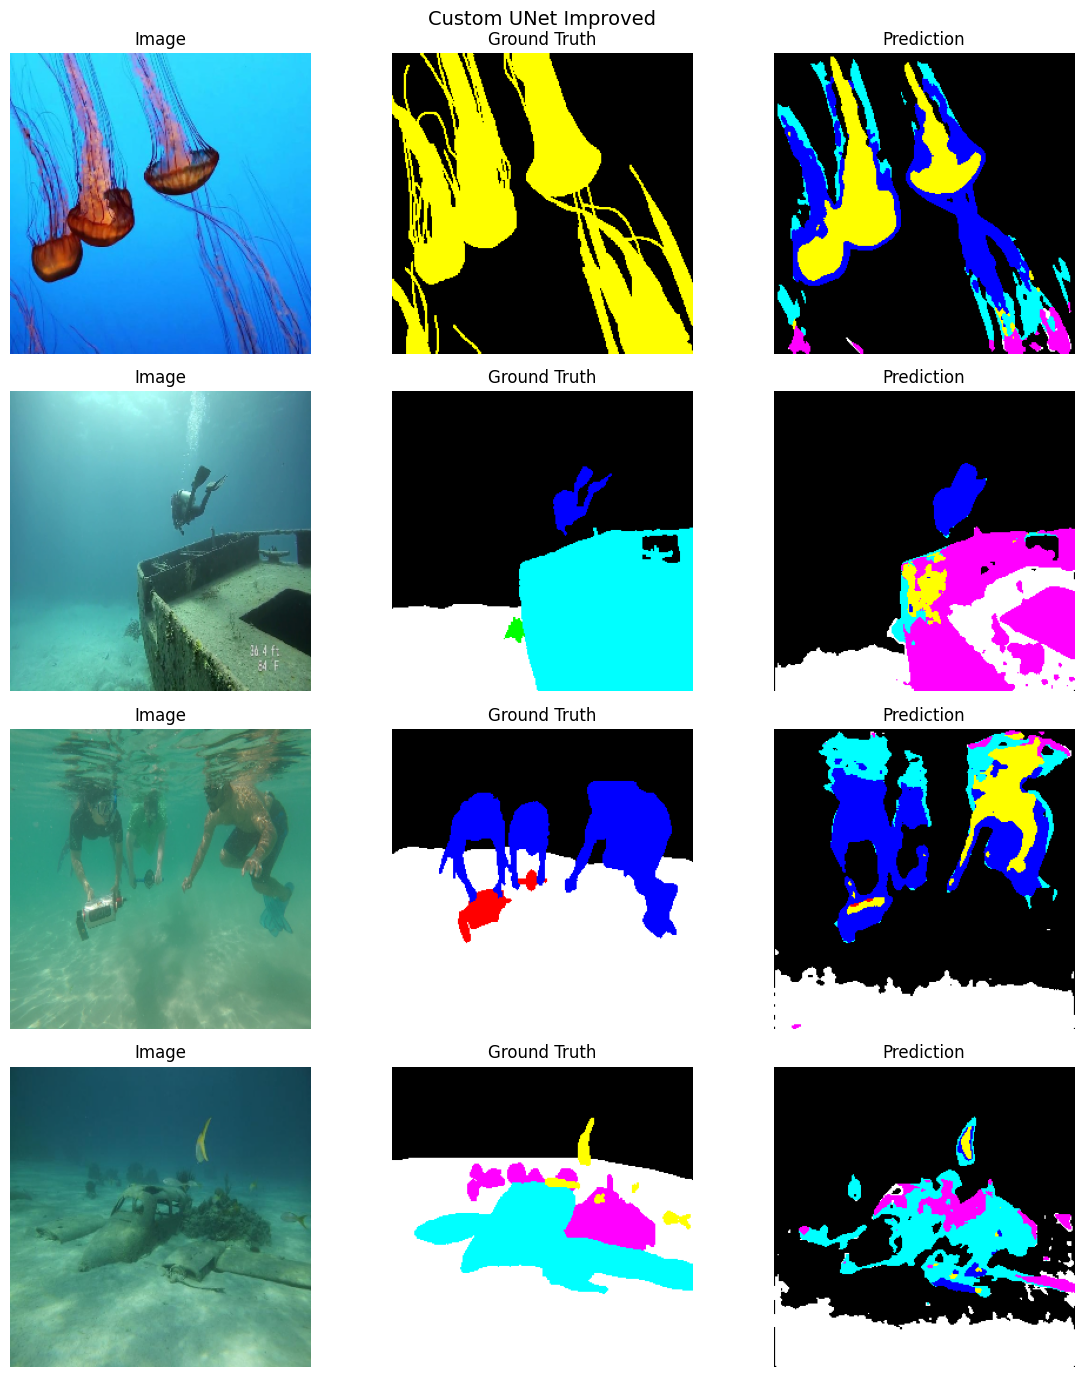

In [30]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def mask_to_rgb(mask: np.ndarray) -> np.ndarray:
    return VIZ_COLORS[mask]


VIZ_COLORS = np.array(PALETTE, dtype=np.uint8)

@torch.no_grad()
def visualize_predictions(model, dataset, device, n=4, title=""):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3.5))
    indices = np.random.choice(len(dataset), n, replace=False)

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).squeeze().cpu().numpy()
        img_np = denormalize(img)
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_to_rgb(mask.numpy()))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(mask_to_rgb(pred))
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

unet_baseline.load_state_dict(torch.load("unet_baseline_best.pth", map_location=DEVICE))
visualize_predictions(unet_improved, test_dataset, DEVICE, n=4, title="UNet ResNet34")

unet_custom_imp.load_state_dict(torch.load("unet_custom_imp_best.pth", map_location=DEVICE))
visualize_predictions(unet_custom_imp, test_dataset, DEVICE, n=4, title="Custom UNet Improved")

### Выводы по улучшению бейзлайна

1. **Смена энкодера на EfficientNet-b3** дала наибольший прирост:
   mIoU 0.361 → 0.536 (+48%). Более мощный энкодер критичен 
   для сложных подводных текстур.
2. **UNet ResNet34 + аугментации + Dice Loss** деградировал 
   (0.361 → 0.262) из-за несовместимости lr=4e-3 с масштабом 
   градиентов Dice Loss — отрицательный результат эксперимента.
3. **ReduceLROnPlateau** стабилизировал обучение EfficientNet-b3 
   — Val Loss снижался без скачков на протяжении всех 20 эпох.

### Выводы по кастомной реализации

1. Кастомный U-Net baseline (mIoU=0.332) сопоставим с smp 
   бейзлайном (0.361) — разрыв 8%, архитектура реализована корректно.
2. После применения техник из п.3 кастомный UNet деградировал 
   (0.332 → 0.247) по той же причине что и ResNet34 improved — 
   нестабильность оптимизации с Dice Loss.
3. Главный вывод: предобученный энкодер важнее архитектуры декодера.
   UNet EfficientNet-b3 превзошёл кастомный UNet на 61% (0.536 vs 0.332)
   при одинаковой структуре декодера.
4. Skip-connections критически важны — без них точная сегментация
   мелких объектов (рыбы, дайверы) невозможна.